In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load cleaned dataset
df = pd.read_csv(r"C:\Users\Jayan Gamage\pima-diabetes-analysis\data\cleaned_diabetes.csv")

# Quick look
print(df.head())
print(df.info())

   Pregnancies  Glucose  BloodPressure  SkinThickness     Insulin   BMI  \
0            6    148.0           72.0       35.00000  155.548223  33.6   
1            1     85.0           66.0       29.00000  155.548223  26.6   
2            8    183.0           64.0       29.15342  155.548223  23.3   
3            1     89.0           66.0       23.00000   94.000000  28.1   
4            0    137.0           40.0       35.00000  168.000000  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose    

In [2]:
# Descriptive statistics
print(df.describe())


       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  121.686763      72.405184      29.153420  155.548223   
std       3.369578   30.435949      12.096346       8.790942   85.021108   
min       0.000000   44.000000      24.000000       7.000000   14.000000   
25%       1.000000   99.750000      64.000000      25.000000  121.500000   
50%       3.000000  117.000000      72.202592      29.153420  155.548223   
75%       6.000000  140.250000      80.000000      32.000000  155.548223   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    32.457464                  0.471876   33.240885    0.348958  
std      6.875151                  0.331329   11.760232    0.476951  
min     18.200000                  

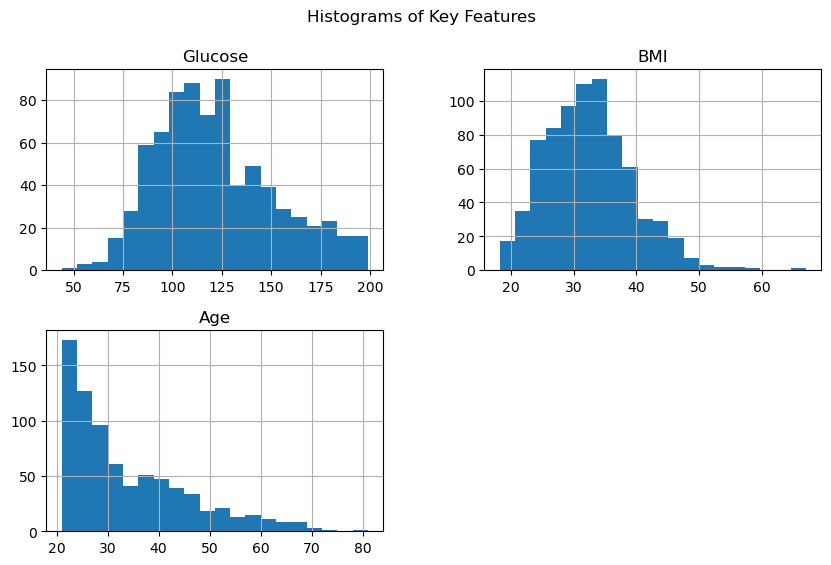

In [14]:
#Visualizations
# Histograms

df[['Glucose','BMI','Age']].hist(bins=20, figsize=(10,6))
plt.suptitle("Histograms of Key Features")
plt.show()


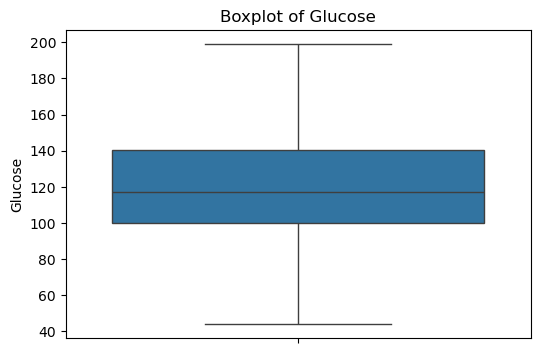

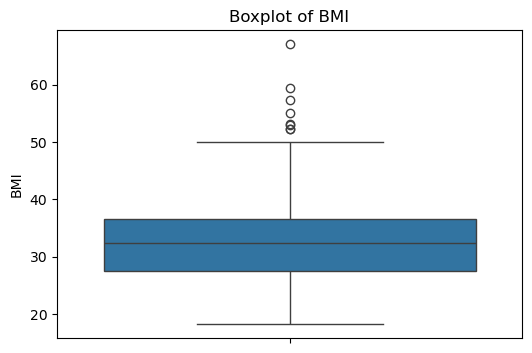

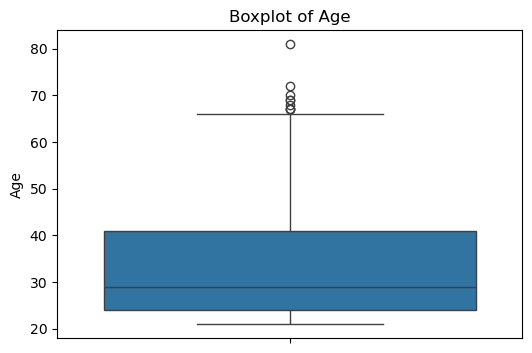

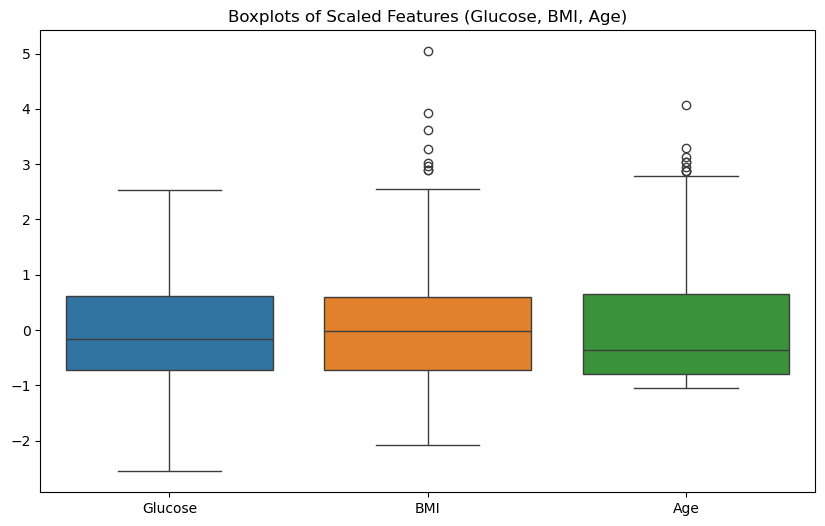

In [12]:
# Individual boxplots for each variable
plt.figure(figsize=(6,4))
sns.boxplot(y=df['Glucose'])
plt.title("Boxplot of Glucose")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(y=df['BMI'])
plt.title("Boxplot of BMI")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(y=df['Age'])
plt.title("Boxplot of Age")
plt.show()

# Scaled boxplots (fair comparison)
scaler = StandardScaler()
scaled = pd.DataFrame(scaler.fit_transform(df[['Glucose','BMI','Age']]),
                      columns=['Glucose','BMI','Age'])

plt.figure(figsize=(10,6))
sns.boxplot(data=scaled)
plt.title("Boxplots of Scaled Features (Glucose, BMI, Age)")
plt.show()


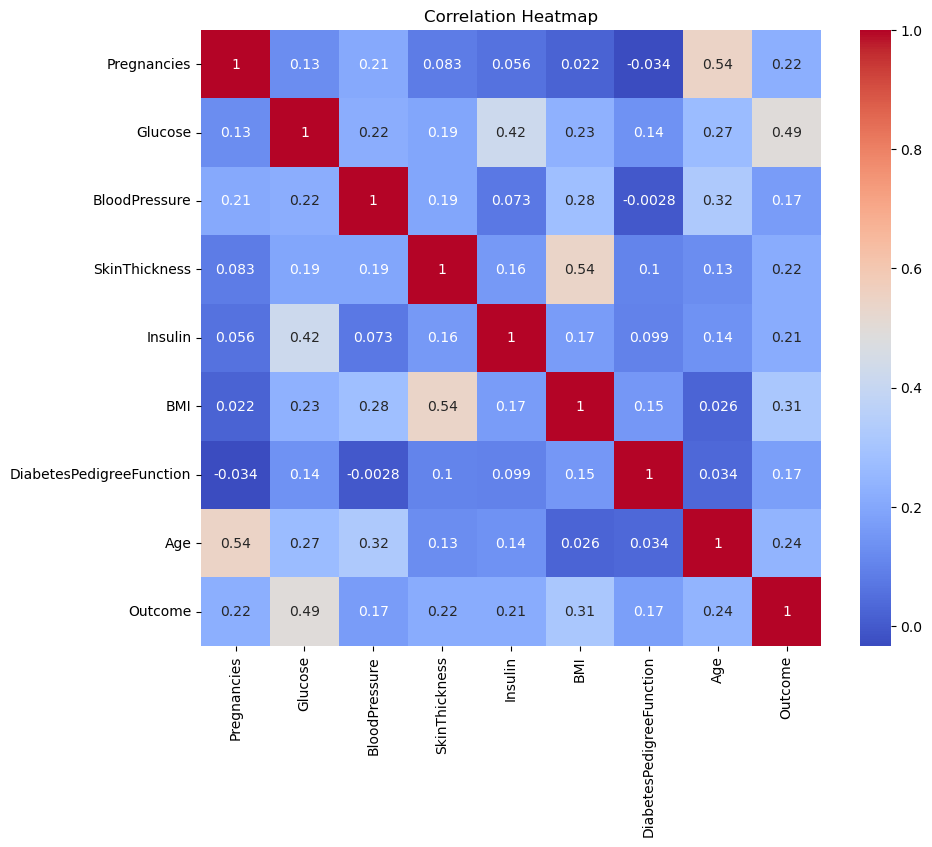

In [11]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()



In [17]:
#Feature Engineering

df['BMI_Category'] = pd.cut(df['BMI'], bins=[0,18.5,25,30,100],
                            labels=['Underweight','Normal','Overweight','Obese'])
df['Age_Group'] = pd.cut(df['Age'], bins=[20,30,50,100],
                         labels=['Young','Middle','Senior'])
df['Glucose_Risk'] = pd.cut(df['Glucose'], bins=[0,100,140,200],
                            labels=['Normal','Prediabetic','High'])

print("\nFeature engineering complete. Sample rows:\n", df[['BMI','BMI_Category','Age','Age_Group','Glucose','Glucose_Risk']].head())


Feature engineering complete. Sample rows:
     BMI BMI_Category  Age Age_Group  Glucose Glucose_Risk
0  33.6        Obese   50    Middle    148.0         High
1  26.6   Overweight   31    Middle     85.0       Normal
2  23.3       Normal   32    Middle    183.0         High
3  28.1   Overweight   21     Young     89.0       Normal
4  43.1        Obese   33    Middle    137.0  Prediabetic


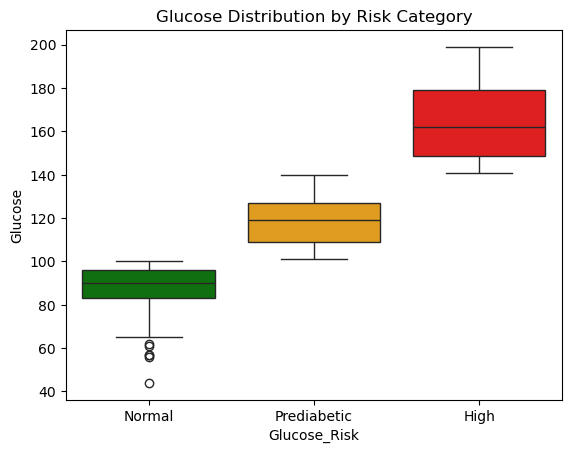

In [24]:
sns.boxplot(x="Glucose_Risk", y="Glucose", hue="Glucose_Risk",
            data=df, palette={"Normal":"green","Prediabetic":"orange","High":"red"},
            legend=False)
plt.title("Glucose Distribution by Risk Category")
plt.show()



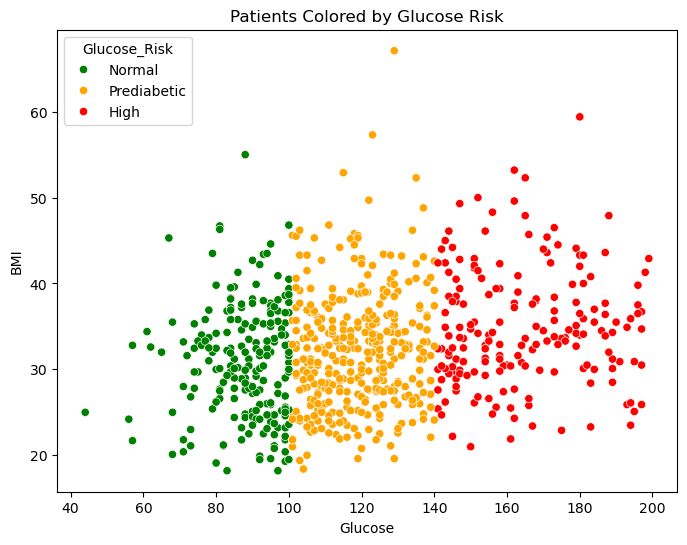

In [31]:
palette = {"Normal":"green", "Prediabetic":"orange", "High":"red"}

plt.figure(figsize=(8,6))
sns.scatterplot(x=df['Glucose'], y=df['BMI'], hue=df['Glucose_Risk'], palette=palette)
plt.title("Patients Colored by Glucose Risk")
plt.show()


In [38]:
# Select meaningful variables
features = ['Glucose','BMI','Age','Pregnancies']

# Scale features
scaler = StandardScaler()
scaled = scaler.fit_transform(df[features])

# Run KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled)

# Cluster means
summary = df.groupby('Cluster')[features].mean()
print("\nCluster Means:\n", summary)



Cluster Means:
             Glucose        BMI        Age  Pregnancies
Cluster                                               
0        137.022974  38.933824  29.093137     1.955882
1        103.477524  28.367552  26.271903     2.311178
2        134.127411  32.597306  46.772532     7.678112


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [39]:
#Risk Categorization (OR vs AND)
print("\n--- Risk Categorization (OR condition) ---")
for cluster_id, row in summary.iterrows():
    glucose, bmi = row['Glucose'], row['BMI']
    if glucose > 140 or bmi > 30:
        risk = "High Risk (red)"
    elif glucose > 100 or bmi > 25:
        risk = "Medium Risk (orange)"
    else:
        risk = "Low Risk (green)"
    print(f"Cluster {cluster_id}: Glucose={glucose:.1f}, BMI={bmi:.1f} → {risk}")

print("\n--- Risk Categorization (AND condition) ---")
for cluster_id, row in summary.iterrows():
    glucose, bmi = row['Glucose'], row['BMI']
    if glucose > 140 and bmi > 30:
        risk = "High Risk (red)"
    elif glucose > 100 and bmi > 25:
        risk = "Medium Risk (orange)"
    else:
        risk = "Low Risk (green)"
    print(f"Cluster {cluster_id}: Glucose={glucose:.1f}, BMI={bmi:.1f} → {risk}")



--- Risk Categorization (OR condition) ---
Cluster 0: Glucose=137.0, BMI=38.9 → High Risk (red)
Cluster 1: Glucose=103.5, BMI=28.4 → Medium Risk (orange)
Cluster 2: Glucose=134.1, BMI=32.6 → High Risk (red)

--- Risk Categorization (AND condition) ---
Cluster 0: Glucose=137.0, BMI=38.9 → Medium Risk (orange)
Cluster 1: Glucose=103.5, BMI=28.4 → Medium Risk (orange)
Cluster 2: Glucose=134.1, BMI=32.6 → Medium Risk (orange)


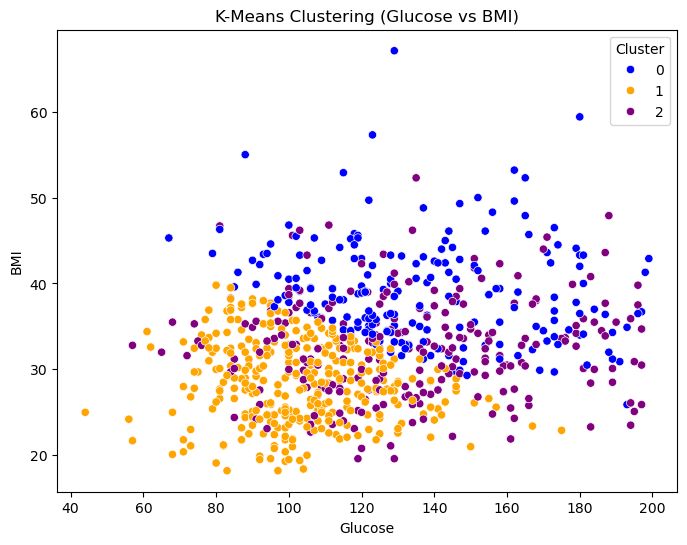

In [40]:
#Scatterplot of Clusters

# Use neutral colors just to distinguish clusters
palette = {0:"blue", 1:"orange", 2:"purple"}

plt.figure(figsize=(8,6))
sns.scatterplot(x=df['Glucose'], y=df['BMI'], hue=df['Cluster'], palette=palette)
plt.title("K-Means Clustering (Glucose vs BMI)")
plt.show()



In [41]:
# Compare clusters with actual diabetes outcome
validation_table = pd.crosstab(df['Cluster'], df['Outcome'],
                               rownames=['Cluster'], colnames=['Diabetes Outcome'])
print(validation_table)

# Normalize to percentages
validation_percent = validation_table.div(validation_table.sum(axis=1), axis=0) * 100
print("\nCluster vs Outcome (%):\n", validation_percent.round(1))


Diabetes Outcome    0    1
Cluster                   
0                 105   99
1                 287   44
2                 108  125

Cluster vs Outcome (%):
 Diabetes Outcome     0     1
Cluster                     
0                 51.5  48.5
1                 86.7  13.3
2                 46.4  53.6


#### Cluster Interpretation
- Cluster 0 → Younger patients, high BMI, moderately high glucose, mixed-risk group
- Cluster 1 → Youngest group, Mostly non-diabetic, lower BMI, lower glucose, lowest risk group
- Cluster 2 → Older patients, higher BMI, elevated glucose, more pregranancies, highest risk group


#### Trends
Higher glucose and BMI values are strongly linked to diabetes risk.

Age adds to the risk: the older cluster had the highest share of diabetics.

Pregnancies showed some influence, but less than glucose and BMI.

Outcome validation confirmed:

Cluster 1 - mostly non‑diabetic (low risk group).

Clusters 0 & 2 - about half diabetic (higher risk groups)

#### Business Insights
Screening programs should focus on people with high glucose or BMI, especially older patients.

Preventive campaigns can target younger, healthier groups to keep them from moving into riskier categories.

Threshold choice matters:

OR logic - broader screening, catches more at‑risk individuals.

AND logic - stricter, highlights only severe cases.

Healthcare resource allocation: prioritize monitoring and interventions for clusters with ~50% diabetic prevalence, while focusing on prevention for the lower‑risk cluster.